In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.least_squares import LinearRegression, PowerLawRegression
from src.SGD import SGD, NoisyGD
from scheduled import WSDSchedule, ConstantSchedule
from src.new_schedules.polynomial import PolynomialSchedule
from src.compute import Computations

In [ ]:
T=100
sigma = 0.1
dim = 10

eta = 0.1

model = PowerLawRegression(dim=dim, sigma=sigma, exponent=2)

wsd = WSDSchedule(steps=T, base_lr=eta, cooldown_len=0.4)
constant = ConstantSchedule(steps=T, base_lr=eta)
polynomial = PolynomialSchedule(steps=T, base_lr=eta, exponent=0.5)

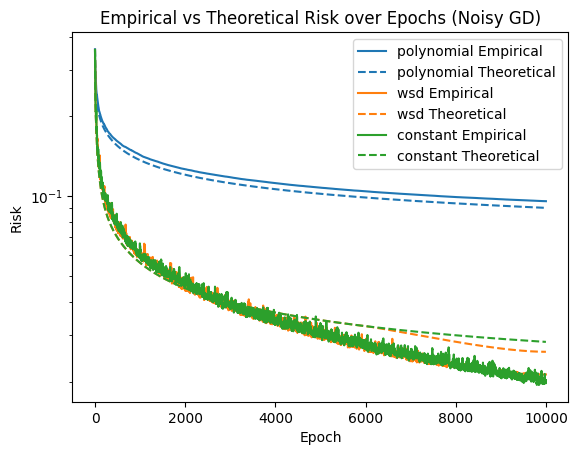

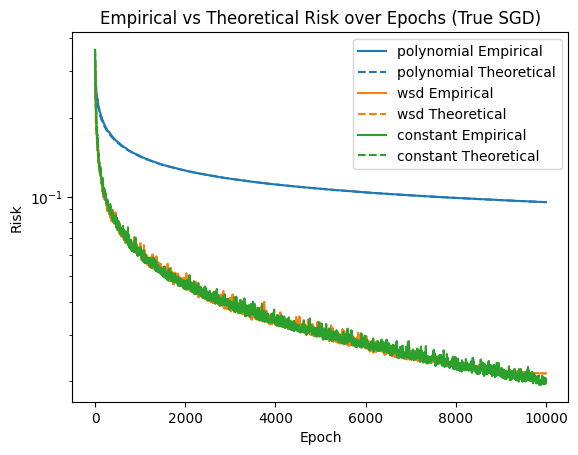

({'polynomial': array([[0.34920092],
         [0.3421263 ],
         [0.3361969 ],
         ...,
         [0.0955305 ],
         [0.09552881],
         [0.09552746]]),
  'wsd': array([[0.35177542],
         [0.33604888],
         [0.32029879],
         ...,
         [0.02136862],
         [0.02136862],
         [0.02136862]]),
  'constant': array([[0.36056428],
         [0.3516445 ],
         [0.33361167],
         ...,
         [0.01972657],
         [0.01957135],
         [0.01983909]])},
 {'polynomial': array([0.36446342, 0.34611017, 0.33374378, ..., 0.09550119, 0.09549961,
         0.09549803]),
  'wsd': array([0.36446342, 0.34611017, 0.33023582, ..., 0.0214046 , 0.0214046 ,
         0.02140459]),
  'constant': array([0.36446342, 0.34611017, 0.33023582, ..., 0.02015037, 0.02014904,
         0.02014771])})

In [3]:
n = 10
x0 = np.random.multivariate_normal(np.zeros(dim), np.eye(dim))

computations_noisyGD = Computations(model, schedules=[polynomial, wsd, constant], sgd_class=NoisyGD)
computations_SGD = Computations(model, schedules=[polynomial, wsd, constant], sgd_class=SGD)

#empirical = computations_noisyGD.compute_all_empirical_risks(x0, n_runs=n, plot=True)
#theoretical = computations_noisyGD.compute_all_theoretical_risks(x0, plot=True)
#empirical_SGD = computations_SGD.compute_all_empirical_risks(x0, n_runs=n, plot=True)
#theoretical_SGD = computations_SGD.compute_all_theoretical_risks(x0, plot=True)

computations_noisyGD.compute_all_risks(x0, n_runs=n, plot=True)
computations_SGD.compute_all_risks(x0, n_runs=n, plot=True)

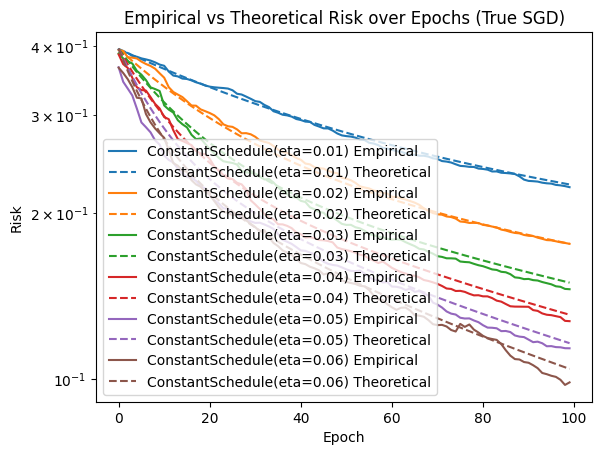

({'ConstantSchedule(eta=0.01)': array([[0.39516898],
         [0.39049836],
         [0.38933124],
         [0.38449717],
         [0.38321877],
         [0.38061989],
         [0.37901336],
         [0.37713166],
         [0.37435096],
         [0.37089998],
         [0.36901615],
         [0.36026818],
         [0.35428846],
         [0.35304894],
         [0.34983194],
         [0.34927482],
         [0.34726809],
         [0.34446295],
         [0.34251083],
         [0.33995668],
         [0.33826093],
         [0.3373597 ],
         [0.33678301],
         [0.33630668],
         [0.33558995],
         [0.33322434],
         [0.32840223],
         [0.32735253],
         [0.32451393],
         [0.32157838],
         [0.31841487],
         [0.31741907],
         [0.31346949],
         [0.3106437 ],
         [0.30529097],
         [0.30338355],
         [0.30089661],
         [0.30006686],
         [0.29850865],
         [0.29555695],
         [0.29429242],
         [0.29238138],
    

In [17]:
n = 10
x0 = np.random.multivariate_normal(np.zeros(dim), np.eye(dim))

schedules = [ConstantSchedule(steps=T, base_lr=eta) for eta in np.linspace(0.01, 0.06, num=6)]
schedules_names = [f"ConstantSchedule(eta={eta:.2f})" for eta in np.linspace(0.01, 0.06, num=6)]
computations_SGD_many = Computations(model, schedules=schedules, schedules_names=schedules_names, sgd_class=SGD)
computations_SGD_many.compute_all_risks(x0, n_runs=n, plot=True)
